This jupyter notebook shows a demo of discoverying the effective gene pairs that are important to cell-cell colocalization by running the perturbation analysis of SpatialFormer.

In principle, the perturbation analysis includes the following steps:
1. Replace each gene pairs with their counterparts.
2. Inspecting the perturbation results of the genes.
3. Select the top k most effective gene pairs and analyze their effects.


It takes about 3-4 hours to get the gene pairs

# Prerequisite:

python perturbation_analysis.py -ct1 Epithelial -ct2 Myoepithelial -adata /home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/croped_sdata_Xenium_breast.h5ad -pair_num 100 -cci /home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/VUILD96MF_croped_cell_id.npy -ts Breast -cd Disease -cache_dir /home/sxr280/Spatialformer/cache/ -base_dir /home/sxr280/Spatialformer_6_10 -rd 10 -out_dir /home/sxr280/Spatialformer/downstream/cell_cell_communication/data


In [1]:
import pickle
import numpy as np
from tqdm import tqdm
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import sys
sys.path.append("/home/sxr280/Spatialformer_6_10/utils")
from utils import stat_test, ovlp_database, filter_df

# all_infos = pickle.load(open("/scratch/project_465001027/Spatialformer/downstream/cell_cell_communication/data/all_infos_alllung_crop_id.pkl", "rb"))

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transfer the results to the dataframe.
- Calculate the mean gene expression level
- Use the student T-test to get the p-value of the gene pairs, and set the null hyphothesis as X~N(0,1)

In [2]:
import json
with open("/home/sxr280/Spatialformer_6_10/tokenizer/tokenv4.json", "r") as f:
    vocab = json.load(f)
    vocab = {j:i for i,j in vocab.items()}

In [3]:
all_infos = pickle.load(open("/home/sxr280/Spatialformer/downstream/cell_cell_communication/data/all_infos_alllung_crop_id_Epithelial_Myoepithelial.pkl", "rb"))
#Optional 1: use the CellChat database
database_path1 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/ligand_receptor_database.csv"
#Optional 2: use the Cellnest database
database_path2 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/CellNEST_database.csv"
myo_epi_pair_df = stat_test(all_infos, vocab)
myo_epi_pair_df = ovlp_database(myo_epi_pair_df, database_path1, database_path2)
myo_epi_ranked_df = filter_df(myo_epi_pair_df)

100%|██████████| 16018/16018 [00:07<00:00, 2172.20it/s]
/home/sxr280/Spatialformer_6_10/utils/utils.py:1624: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["adj_P_value"] = pvals_corrected


In [7]:
myo_epi_ranked_df

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
1310,"(MYH11, PTN)",MYH11,PTN,-0.010655,9.303279,-3.154422,0.001014,122,"[[fljgfdej-1, fljfmpeg-1], [fljfmpeg-1, fljgfd...","[-0.31290078, -0.2140032, -0.11348623, -0.0859...",False,-0.154543,-1,0.004030
1420,"(KRT14, KRT7)",KRT14,KRT7,-0.010230,19.051282,-2.284174,0.012559,78,"[[fkddgflk-1, fkdblbll-1], [flfigenn-1, flfkan...","[-0.23415506, -0.16106588, -0.15019006, -0.109...",False,-0.148347,-1,0.019433
1929,"(KRT7, ANKRD30A)",KRT7,ANKRD30A,-0.009953,23.472222,-2.830380,0.002777,108,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.24829865, -0.20224816, -0.1380198, -0.0993...",False,-0.144315,-1,0.007788
682,"(KRT7, TACSTD2)",KRT7,TACSTD2,-0.009791,24.127273,-2.988830,0.001731,110,"[[fkblapik-1, fkblkkfp-1], [flfigenn-1, flfkan...","[-0.20886439, -0.1924851, -0.13206273, -0.1221...",False,-0.141948,-1,0.006205
1533,"(LDHB, KRT7)",LDHB,KRT7,-0.009528,25.150000,-2.391610,0.009991,60,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.1862396, -0.11866319, -0.09677583, -0.0514...",False,-0.138113,-1,0.017379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,"(ACTA2, CCND1)",ACTA2,CCND1,-0.001578,18.135135,-2.140068,0.017846,74,"[[flfhkghb-1, flfghdef-1], [fndpdkji-1, fndpao...","[-0.024849176, -0.022876918, -0.0148591995, -0...",False,-0.022779,-1,0.024517
97,"(MYLK, MLPH)",MYLK,MLPH,-0.001559,13.069444,-2.069677,0.021061,72,"[[fkblapik-1, fkblkkfp-1], [fkblkkfp-1, fkblap...","[-0.036667258, -0.023165047, -0.011918843, -0....",False,-0.022508,-1,0.027404
974,"(TACSTD2, ADAM9)",TACSTD2,ADAM9,-0.001493,21.703704,-2.450471,0.008801,54,"[[fkdblbll-1, fkddgflk-1], [fndpdkji-1, fndpao...","[-0.020775497, -0.017322421, -0.009297729, -0....",False,-0.021553,-1,0.015802
2182,"(SVIL, KRT8)",SVIL,KRT8,-0.001463,18.982759,-2.241190,0.014462,58,"[[fkdblbll-1, fkddgflk-1], [fkddgflk-1, fkdblb...","[-0.026753545, -0.017184913, -0.009414792, -0....",False,-0.021116,-1,0.021245


In [4]:
myo_epi_ranked_df.sort_values("P_value")

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
847,"(PTN, ACTA2)",PTN,ACTA2,-0.007347,11.432432,-6.075125,5.060054e-09,148,"[[fleeglnc-1, flekbbam-1], [fkddgflk-1, fkdblb...","[-0.07204813, -0.06265682, -0.0557732, -0.0554...",False,-0.106388,-1,7.438280e-07
110,"(ACTA2, DST)",ACTA2,DST,-0.005455,9.988095,-5.121233,4.146238e-07,168,"[[fnebmfbd-1, fneebajm-1], [fkddgflk-1, fkdblb...","[-0.07278645, -0.0710845, -0.061951518, -0.056...",False,-0.078916,-1,3.047485e-05
1316,"(MYH11, ACTA2)",MYH11,ACTA2,-0.004897,12.131944,-4.304795,1.542326e-05,144,"[[fljgfdej-1, fljfmpeg-1], [fkddgflk-1, fkdblb...","[-0.10031867, -0.05638522, -0.053982437, -0.04...",False,-0.070817,-1,5.215243e-04
937,"(ACTA2, NARS)",ACTA2,NARS,-0.004108,14.343750,-4.480468,1.603092e-05,64,"[[fnliagog-1, fnlhfnin-1], [fnlhfnin-1, fnliag...","[-0.03163159, -0.023636937, -0.022404075, -0.0...",False,-0.059382,-1,5.215243e-04
940,"(ACTA2, ADAM9)",ACTA2,ADAM9,-0.003157,14.852941,-4.424048,1.824021e-05,68,"[[fndpdkji-1, fndpaojl-1], [fndpaojl-1, fndpdk...","[-0.022960722, -0.018163621, -0.016245544, -0....",False,-0.045624,-1,5.215243e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,"(SERPINA3, CDH1)",SERPINA3,CDH1,-0.002872,21.548387,-1.716859,4.553949e-02,62,"[[fnliagog-1, fnlhfnin-1], [fnlhfnin-1, fnliag...","[-0.08523148, -0.03064996, -0.027706504, -0.02...",False,-0.041494,-1,4.681332e-02
720,"(SFRP1, MYLK)",SFRP1,MYLK,-0.002299,5.177419,-1.684121,4.734722e-02,124,"[[fnliagog-1, fnlhfnin-1], [fkdpmegp-1, fkdnef...","[-0.08612645, -0.05245471, -0.043481052, -0.03...",False,-0.033201,-1,4.833362e-02
1331,"(MYH11, NARS)",MYH11,NARS,-0.003681,13.807692,-1.693528,4.822754e-02,52,"[[fnliagog-1, fnlhfnin-1], [fndpdkji-1, fndpao...","[-0.06637341, -0.05138135, -0.042194903, -0.04...",False,-0.053200,-1,4.858226e-02
2924,"(MYH11, CDH1)",MYH11,CDH1,-0.002653,9.316667,-1.688973,4.825177e-02,60,"[[fnliagog-1, fnlhfnin-1], [fkddgflk-1, fkdblb...","[-0.061257303, -0.041016042, -0.03414148, -0.0...",False,-0.038320,-1,4.858226e-02


In [5]:
myo_epi_ranked_df.shape[0]*0.2

29.400000000000002

In [6]:
myo_epi_ranked_df[myo_epi_ranked_df["ligand_receptor"] == True]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
1350,"(SDC4, PTN)",SDC4,PTN,-0.004833,9.016129,-2.67703,0.004764,62,"[[fljgfdej-1, fljfmpeg-1], [fkdijkga-1, fkdlll...","[-0.068342626, -0.05285126, -0.040603995, -0.0...",True,-0.069893,-1,0.011116


In [55]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "GATA3") | (myo_epi_ranked_df["gene2"] == "GATA3")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
1957,"(GATA3, ANKRD30A)",GATA3,ANKRD30A,-0.00341,29.297619,-2.219316,0.014597,84,"[[fnliagog-1, fnlhfnin-1], [fnlhfnin-1, fnliag...","[-0.09188706, -0.063810885, -0.04162556, -0.04...",False,-0.049287,-1,0.021245


In [56]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "ESR1") | (myo_epi_ranked_df["gene2"] == "ESR1")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value


In [57]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "MLPH") | (myo_epi_ranked_df["gene2"] == "MLPH")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
685,"(KRT7, MLPH)",KRT7,MLPH,-0.005818,24.230769,-2.746068,0.004156,52,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.08588344, -0.048649073, -0.04277906, -0.02...",False,-0.084185,-1,0.010015
118,"(ACTA2, MLPH)",ACTA2,MLPH,-0.005669,16.075000,-3.589698,0.000286,80,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.09347296, -0.067005515, -0.030268729, -0.0...",False,-0.082012,-1,0.002206
139,"(TACSTD2, MLPH)",TACSTD2,MLPH,-0.004185,22.724138,-3.267661,0.000920,58,"[[fkblapik-1, fkblkkfp-1], [fnebmfbd-1, fneeba...","[-0.045322716, -0.038728833, -0.029953659, -0....",False,-0.060506,-1,0.003977
3489,"(ANKRD30A, MLPH)",ANKRD30A,MLPH,-0.004058,24.589286,-2.339203,0.011492,56,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.07037377, -0.06349224, -0.01621914, -0.010...",False,-0.058660,-1,0.018521
624,"(SERPINA3, MLPH)",SERPINA3,MLPH,-0.002339,27.450000,-1.722187,0.045137,60,"[[fkblkkfp-1, fkblapik-1], [fkblapik-1, fkblkk...","[-0.048956633, -0.048634917, -0.023737252, -0....",False,-0.033783,-1,0.046727
97,"(MYLK, MLPH)",MYLK,MLPH,-0.001559,13.069444,-2.069677,0.021061,72,"[[fkblapik-1, fkblkkfp-1], [fkblkkfp-1, fkblap...","[-0.036667258, -0.023165047, -0.011918843, -0....",False,-0.022508,-1,0.027404


In [58]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "ANKRD30A") | (myo_epi_ranked_df["gene2"] == "ANKRD30A")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
1929,"(KRT7, ANKRD30A)",KRT7,ANKRD30A,-0.009953,23.472222,-2.830380,0.002777,108,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.24829865, -0.20224816, -0.1380198, -0.0993...",False,-0.144315,-1,0.007788
1715,"(ENAH, ANKRD30A)",ENAH,ANKRD30A,-0.007690,26.818182,-3.356086,0.000662,66,"[[flfigenn-1, flfkanlk-1], [fnliagog-1, fnlhfn...","[-0.07978475, -0.078089476, -0.07760483, -0.04...",False,-0.111368,-1,0.003475
3501,"(ANKRD30A, ERBB2)",ANKRD30A,ERBB2,-0.007478,24.000000,-2.632263,0.005172,74,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.14965868, -0.12494826, -0.069663286, -0.03...",False,-0.108287,-1,0.011392
3261,"(CDH1, ANKRD30A)",CDH1,ANKRD30A,-0.007338,15.482759,-2.363417,0.010770,58,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.11842221, -0.098864734, -0.071955144, -0.0...",False,-0.106255,-1,0.017991
3502,"(ANKRD30A, EPCAM)",ANKRD30A,EPCAM,-0.006571,25.810345,-2.976881,0.002134,58,"[[flfigenn-1, flfkanlk-1], [flfigenn-1, flfkan...","[-0.09084308, -0.05546534, -0.052908897, -0.03...",False,-0.095113,-1,0.006820
953,"(ACTA2, ANKRD30A)",ACTA2,ANKRD30A,-0.006345,15.342105,-3.951660,0.000059,152,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.15005338, -0.12036699, -0.08410078, -0.080...",False,-0.091828,-1,0.000869
3442,"(CTTN, ANKRD30A)",CTTN,ANKRD30A,-0.006218,16.589286,-2.456864,0.008599,56,"[[flfigenn-1, flfkanlk-1], [fnliagog-1, fnlhfn...","[-0.08370632, -0.080338955, -0.07819414, -0.02...",False,-0.089984,-1,0.015801
981,"(TACSTD2, ANKRD30A)",TACSTD2,ANKRD30A,-0.005025,22.459016,-4.013325,0.000052,122,"[[flfigenn-1, flfkanlk-1], [flfigenn-1, flfkan...","[-0.082454205, -0.058286965, -0.05513233, -0.0...",False,-0.072675,-1,0.000851
3495,"(ANKRD30A, KRT8)",ANKRD30A,KRT8,-0.004815,22.268293,-3.303927,0.000711,82,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.069359064, -0.048947632, -0.04655975, -0.0...",False,-0.069632,-1,0.003602
3465,"(MDM2, ANKRD30A)",MDM2,ANKRD30A,-0.004415,17.528571,-3.294878,0.000778,70,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.07168168, -0.030936599, -0.027297854, -0.0...",False,-0.063837,-1,0.003728


In [59]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "MLPH") | (myo_epi_ranked_df["gene2"] == "MLPH")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
685,"(KRT7, MLPH)",KRT7,MLPH,-0.005818,24.230769,-2.746068,0.004156,52,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.08588344, -0.048649073, -0.04277906, -0.02...",False,-0.084185,-1,0.010015
118,"(ACTA2, MLPH)",ACTA2,MLPH,-0.005669,16.075000,-3.589698,0.000286,80,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.09347296, -0.067005515, -0.030268729, -0.0...",False,-0.082012,-1,0.002206
139,"(TACSTD2, MLPH)",TACSTD2,MLPH,-0.004185,22.724138,-3.267661,0.000920,58,"[[fkblapik-1, fkblkkfp-1], [fnebmfbd-1, fneeba...","[-0.045322716, -0.038728833, -0.029953659, -0....",False,-0.060506,-1,0.003977
3489,"(ANKRD30A, MLPH)",ANKRD30A,MLPH,-0.004058,24.589286,-2.339203,0.011492,56,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.07037377, -0.06349224, -0.01621914, -0.010...",False,-0.058660,-1,0.018521
624,"(SERPINA3, MLPH)",SERPINA3,MLPH,-0.002339,27.450000,-1.722187,0.045137,60,"[[fkblkkfp-1, fkblapik-1], [fkblapik-1, fkblkk...","[-0.048956633, -0.048634917, -0.023737252, -0....",False,-0.033783,-1,0.046727
97,"(MYLK, MLPH)",MYLK,MLPH,-0.001559,13.069444,-2.069677,0.021061,72,"[[fkblapik-1, fkblkkfp-1], [fkblkkfp-1, fkblap...","[-0.036667258, -0.023165047, -0.011918843, -0....",False,-0.022508,-1,0.027404


In [60]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "DST") | (myo_epi_ranked_df["gene2"] == "DST")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
677,"(KRT7, DST)",KRT7,DST,-0.005871,16.888889,-3.183621,9.179248e-04,126,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.15661287, -0.11127734, -0.06844604, -0.056...",False,-0.084951,-1,0.003977
110,"(ACTA2, DST)",ACTA2,DST,-0.005455,9.988095,-5.121233,4.146238e-07,168,"[[fnebmfbd-1, fneebajm-1], [fkddgflk-1, fkdblb...","[-0.07278645, -0.0710845, -0.061951518, -0.056...",False,-0.078916,-1,0.000030
338,"(MYH11, DST)",MYH11,DST,-0.005364,7.949275,-3.556503,2.583125e-04,138,"[[fljgfdej-1, fljfmpeg-1], [fljfmpeg-1, fljgfd...","[-0.14543754, -0.069150805, -0.059043407, -0.0...",False,-0.077589,-1,0.002110
380,"(KRT14, DST)",KRT14,DST,-0.004836,11.281250,-1.960789,2.641617e-02,96,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.18059444, -0.133026, -0.044392228, -0.0435...",False,-0.069944,-1,0.031571
443,"(LDHB, DST)",LDHB,DST,-0.003932,13.821429,-2.968902,2.210294e-03,56,"[[fkblapik-1, fkbmngeo-1], [flfigenn-1, flfkan...","[-0.050604284, -0.037053525, -0.03540662, -0.0...",False,-0.056845,-1,0.006913
619,"(SERPINA3, DST)",SERPINA3,DST,-0.002927,19.707692,-2.514564,6.573687e-03,130,"[[fkblapik-1, fkbmngeo-1], [fkblapik-1, fkblkk...","[-0.07006395, -0.06578171, -0.0608418, -0.0593...",False,-0.042291,-1,0.013355
68,"(PTN, DST)",PTN,DST,-0.002914,8.100000,-2.807685,2.853981e-03,140,"[[fleeglnc-1, flekbbam-1], [fndpdkji-1, fndpao...","[-0.05040276, -0.050195515, -0.043537617, -0.0...",False,-0.042103,-1,0.007788
3484,"(ANKRD30A, DST)",ANKRD30A,DST,-0.002610,11.985507,-2.084131,1.950276e-02,138,"[[flfigenn-1, flfkanlk-1], [fnlhfnin-1, fnliag...","[-0.08499062, -0.06810135, -0.060403824, -0.05...",False,-0.037704,-1,0.026302
422,"(KRT5, DST)",KRT5,DST,-0.002514,12.135135,-1.778661,3.972941e-02,74,"[[flfigenn-1, flfkanlk-1], [fkblapik-1, fkblkk...","[-0.05720359, -0.046185106, -0.044858873, -0.0...",False,-0.036318,-1,0.042629
215,"(SVIL, DST)",SVIL,DST,-0.002289,10.445946,-2.326069,1.139751e-02,74,"[[fkblapik-1, fkbmngeo-1], [fldpmbjo-1, flegcc...","[-0.04326254, -0.038980663, -0.02115184, -0.01...",False,-0.033059,-1,0.018521


In [61]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "ACTA2") | (myo_epi_ranked_df["gene2"] == "ACTA2")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
111,"(ACTA2, ERBB2)",ACTA2,ERBB2,-0.007514,16.696078,-4.164214,3.294829e-05,102,"[[fkddgflk-1, fkdblbll-1], [flfigenn-1, flfkan...","[-0.105846465, -0.079187274, -0.07879293, -0.0...",False,-0.108807,-1,6.919140e-04
847,"(PTN, ACTA2)",PTN,ACTA2,-0.007347,11.432432,-6.075125,5.060054e-09,148,"[[fleeglnc-1, flekbbam-1], [fkddgflk-1, fkdblb...","[-0.07204813, -0.06265682, -0.0557732, -0.0554...",False,-0.106388,-1,7.438280e-07
917,"(ACTA2, KRT14)",ACTA2,KRT14,-0.007325,14.696078,-2.671346,4.403842e-03,102,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.19928783, -0.13174206, -0.10038203, -0.070...",False,-0.106062,-1,1.044137e-02
951,"(ACTA2, KRT7)",ACTA2,KRT7,-0.007246,19.897059,-3.495112,3.207659e-04,136,"[[flfigenn-1, flfkanlk-1], [flfkanlk-1, flfige...","[-0.1795327, -0.12513489, -0.11539304, -0.0897...",False,-0.104924,-1,2.206198e-03
2085,"(ACTA2, LARS)",ACTA2,LARS,-0.007173,16.265625,-3.463234,4.824623e-04,64,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.1022259, -0.074323535, -0.037564516, -0.02...",False,-0.103854,-1,2.727767e-03
115,"(ACTA2, TACSTD2)",ACTA2,TACSTD2,-0.007046,16.322368,-3.654845,1.772710e-04,152,"[[fkblapik-1, fkblkkfp-1], [fkddgflk-1, fkdblb...","[-0.17747808, -0.14547092, -0.10485172, -0.102...",False,-0.102014,-1,1.560523e-03
941,"(ACTA2, LDHB)",ACTA2,LDHB,-0.006775,18.062500,-3.304485,7.862769e-04,64,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.10837573, -0.07415563, -0.023522079, -0.02...",False,-0.098080,-1,3.728474e-03
3783,"(ACTA2, SH3YL1)",ACTA2,SH3YL1,-0.006616,13.714286,-2.926411,2.488168e-03,56,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.10273361, -0.06568557, -0.025780737, -0.02...",False,-0.095767,-1,7.315215e-03
953,"(ACTA2, ANKRD30A)",ACTA2,ANKRD30A,-0.006345,15.342105,-3.951660,5.941587e-05,152,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.15005338, -0.12036699, -0.08410078, -0.080...",False,-0.091828,-1,8.686327e-04
2735,"(ACTA2, AR)",ACTA2,AR,-0.005939,16.185185,-2.439593,9.041753e-03,54,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.1036281, -0.069876134, -0.021779478, -0.01...",False,-0.085930,-1,1.601371e-02


In [62]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "MYLK") | (myo_epi_ranked_df["gene2"] == "MYLK")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
914,"(MYLK, KRT7)",MYLK,KRT7,-0.004654,16.245902,-2.299632,0.011592,122,"[[flfigenn-1, flfkanlk-1], [fkddgflk-1, fkdblb...","[-0.16052967, -0.13294268, -0.09712911, -0.071...",False,-0.067293,-1,0.018521
840,"(PTN, MYLK)",PTN,MYLK,-0.003860,7.250000,-4.231618,0.000021,136,"[[fldpmbjo-1, flegcclk-1], [fleeglnc-1, flekbb...","[-0.048412204, -0.047925472, -0.043953657, -0....",False,-0.055803,-1,0.000522
1309,"(MYH11, MYLK)",MYH11,MYLK,-0.003028,7.307692,-2.000267,0.023786,130,"[[fljgfdej-1, fljfmpeg-1], [fljfmpeg-1, fljgfd...","[-0.15203136, -0.07791948, -0.044048727, -0.03...",False,-0.043748,-1,0.029382
2712,"(MYLK, CDH1)",MYLK,CDH1,-0.002926,7.763889,-1.818281,0.036620,72,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.094980955, -0.05431688, -0.021092117, -0.0...",False,-0.042275,-1,0.040172
90,"(MYLK, ERBB2)",MYLK,ERBB2,-0.002778,13.706522,-2.698509,0.004151,92,"[[flfigenn-1, flfkanlk-1], [fkblapik-1, fkblkk...","[-0.048072934, -0.04623422, -0.039272904, -0.0...",False,-0.040128,-1,0.010015
885,"(MYLK, ACTA2)",MYLK,ACTA2,-0.002452,9.543210,-2.398001,0.008815,162,"[[fkddgflk-1, fkdblbll-1], [fkdblbll-1, fkddgf...","[-0.12569976, -0.07332122, -0.033580184, -0.02...",False,-0.035414,-1,0.015802
720,"(SFRP1, MYLK)",SFRP1,MYLK,-0.002299,5.177419,-1.684121,0.047347,124,"[[fnliagog-1, fnlhfnin-1], [fkdpmegp-1, fkdnef...","[-0.08612645, -0.05245471, -0.043481052, -0.03...",False,-0.033201,-1,0.048334
1349,"(SDC4, MYLK)",SDC4,MYLK,-0.002291,7.666667,-2.166467,0.017163,60,"[[fkdijkga-1, fkdlllnh-1], [fldpmbjo-1, flegcc...","[-0.038082242, -0.030019939, -0.021194756, -0....",False,-0.033094,-1,0.023802
904,"(MYLK, LDHB)",MYLK,LDHB,-0.001949,13.416667,-2.978636,0.002099,60,"[[fkdijkga-1, fkdlllnh-1], [fljlkbok-1, fljllp...","[-0.027776718, -0.015529335, -0.0151901245, -0...",False,-0.028141,-1,0.006820
903,"(MYLK, ADAM9)",MYLK,ADAM9,-0.001918,12.532258,-3.267196,0.000893,62,"[[fkdijkga-1, fkdlllnh-1], [fldpmbjo-1, flegcc...","[-0.021783113, -0.014880896, -0.010964334, -0....",False,-0.027698,-1,0.003977


In [63]:
myo_epi_ranked_df[(myo_epi_ranked_df["gene1"] == "MYH11") | (myo_epi_ranked_df["gene2"] == "MYH11")]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
1310,"(MYH11, PTN)",MYH11,PTN,-0.010655,9.303279,-3.154422,0.001014,122,"[[fljgfdej-1, fljfmpeg-1], [fljfmpeg-1, fljgfd...","[-0.31290078, -0.2140032, -0.11348623, -0.0859...",False,-0.154543,-1,0.004030
1339,"(MYH11, SVIL)",MYH11,SVIL,-0.007917,12.285714,-2.055748,0.022283,56,"[[fljgfdej-1, fljfmpeg-1], [fljfmpeg-1, fljgfd...","[-0.17794561, -0.09571093, -0.06605047, -0.039...",False,-0.114674,-1,0.028413
2291,"(MYH11, SFRP1)",MYH11,SFRP1,-0.006187,7.696429,-2.611783,0.005126,112,"[[fnliagog-1, fnlhfnin-1], [fljgfdej-1, fljfmp...","[-0.15351921, -0.11588645, -0.109242916, -0.09...",False,-0.089531,-1,0.011392
2993,"(KRT5, MYH11)",KRT5,MYH11,-0.005790,13.259259,-3.391042,0.000661,54,"[[flndkide-1, flnfljmj-1], [fljgbfpk-1, fljfmp...","[-0.0636965, -0.03214687, -0.026365459, -0.021...",False,-0.083770,-1,0.003475
338,"(MYH11, DST)",MYH11,DST,-0.005364,7.949275,-3.556503,0.000258,138,"[[fljgfdej-1, fljfmpeg-1], [fljfmpeg-1, fljgfd...","[-0.14543754, -0.069150805, -0.059043407, -0.0...",False,-0.077589,-1,0.002110
1316,"(MYH11, ACTA2)",MYH11,ACTA2,-0.004897,12.131944,-4.304795,0.000015,144,"[[fljgfdej-1, fljfmpeg-1], [fkddgflk-1, fkdblb...","[-0.10031867, -0.05638522, -0.053982437, -0.04...",False,-0.070817,-1,0.000522
343,"(MYH11, TACSTD2)",MYH11,TACSTD2,-0.004577,15.161290,-2.623774,0.004899,124,"[[fkblapik-1, fkblkkfp-1], [fnebmfbd-1, fneeba...","[-0.15146837, -0.09773451, -0.060986638, -0.05...",False,-0.066187,-1,0.011252
4944,"(MYH11, SH3YL1)",MYH11,SH3YL1,-0.004354,12.692308,-2.374166,0.010695,52,"[[fndpdkji-1, fndpaojl-1], [fndpaojl-1, fndpdk...","[-0.07001412, -0.049408793, -0.03833884, -0.01...",False,-0.062948,-1,0.017991
352,"(MYH11, SERPINA3)",MYH11,SERPINA3,-0.003961,21.344828,-2.429687,0.008329,116,"[[fnliagog-1, fnlhfnin-1], [fkblapik-1, fkblkk...","[-0.118750036, -0.06826356, -0.054831207, -0.0...",False,-0.057264,-1,0.015499
1346,"(MYH11, KRT7)",MYH11,KRT7,-0.003946,18.638889,-2.718406,0.003827,108,"[[fnliagog-1, fnlhfnin-1], [fndpdkji-1, fndpao...","[-0.07671994, -0.073666155, -0.06217146, -0.05...",False,-0.057035,-1,0.009536


In [1]:
import os
import sys

# Set R_HOME to your path from Step 1
r_home = "/home/sxr280/miniconda3/envs/spatialformer/lib/R"  
if os.path.exists(r_home):
    os.environ['R_HOME'] = r_home
else:
    raise FileNotFoundError(f"R_HOME path not found: {r_home}")

In [2]:
%%capture
%load_ext rpy2.ipython

In [66]:
filtered_df = myo_epi_pair_df

In [80]:
filtered_df["-log(P_value)"] = -np.log(filtered_df["P_value"])

In [81]:
filtered_df

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,-log(P_value)
0,"(SFRP1, AVPR1A)",SFRP1,AVPR1A,0.049803,0.000000,2.360587,0.872452,2,"[[fkblkkfp-1, fkblapik-1]]",[0.028705359],False,0.737016,1,0.136448
1,"(SFRP1, GJB2)",SFRP1,GJB2,0.091112,11.166667,1.489427,0.901723,6,"[[fledjgkc-1, fldpmbjo-1], [flegcclk-1, fldpmb...","[-0.0023531914, 0.002298236]",False,1.378253,1,0.103448
2,"(SFRP1, IGF1)",SFRP1,IGF1,0.039938,11.000000,1.414189,0.904523,10,"[[flepebng-1, flenaogp-1], [flenaogp-1, flepeb...","[-0.024383605, -0.010534167]",False,0.588004,1,0.100348
3,"(SFRP1, DSC2)",SFRP1,DSC2,-0.006485,11.159091,-1.387747,0.086182,44,"[[fkblapik-1, fkblkkfp-1], [fkblkkfp-1, fkblap...","[-0.15255871, -0.09548199, -0.07123345, -0.044...",False,-0.093862,-1,2.451296
4,"(SFRP1, CD9)",SFRP1,CD9,0.005510,12.750000,2.244914,0.984741,40,"[[fkblapik-1, fkbmngeo-1], [fkbmngeo-1, fkblap...","[-0.026627421, -0.019806206, -0.015702784, -0....",False,0.079719,1,0.015377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16013,"(TCL1A, LYZ)",TCL1A,LYZ,-0.003281,25.000000,-26.256857,0.012117,2,"[[fnmdfcji-1, fnmcncke-1]]",[-0.0034060478],False,-0.047414,-1,4.413140
16014,"(TCL1A, TACSTD2)",TCL1A,TACSTD2,-0.000089,25.500000,-0.107404,0.465943,2,"[[fnmdfcji-1, fnmcncke-1]]",[-0.00092184544],False,-0.001290,-1,0.763692
16015,"(TCL1A, TPD52)",TCL1A,TPD52,-0.006546,26.000000,-6.784346,0.046583,2,"[[fnmdfcji-1, fnmcncke-1]]",[-0.00751096],False,-0.094750,-1,3.066523
16016,"(TCL1A, <SEP>)",TCL1A,<SEP>,-0.020184,26.500000,-11.897599,0.026691,2,"[[fnmcncke-1, fnmdfcji-1]]",[-0.021879971],False,-0.294166,-1,3.623414


In [83]:
filtered_df.sort_values("-log(P_value)", ascending = False)

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,-log(P_value)
125,"(ACTA2, <SEP>)",ACTA2,<SEP>,-0.025456,25.552632,-8.835146,3.427578e-16,190,"[[fkblapik-1, fkblkkfp-1], [fkdblbll-1, fkddgf...","[-0.31835467, -0.2269324, -0.20781076, -0.1482...",False,-0.372012,-1,3.560951e+01
711,"(<SEP>, DST)",<SEP>,DST,-0.014106,22.063218,-8.453865,5.653387e-15,174,"[[flfkanlk-1, flfigenn-1], [fldpmbjo-1, flegcc...","[-0.17621624, -0.09914899, -0.094296515, -0.07...",False,-0.204960,-1,3.280652e+01
717,"(<SEP>, TOMM7)",<SEP>,TOMM7,-0.014808,30.890411,-7.632758,1.410337e-12,146,"[[flfkanlk-1, flfigenn-1], [fkdblbll-1, fkddgf...","[-0.16913521, -0.11209118, -0.076767325, -0.07...",False,-0.215227,-1,2.728719e+01
719,"(<SEP>, <SEP>)",<SEP>,<SEP>,-0.032248,37.680000,-7.928569,1.706414e-12,100,"[[fkblapik-1, fkblkkfp-1], [flfkanlk-1, flfige...","[-0.23982233, -0.19859397, -0.16560352, -0.125...",False,-0.472912,-1,2.709663e+01
146,"(TACSTD2, <SEP>)",TACSTD2,<SEP>,-0.023917,28.937500,-7.345079,5.046840e-12,160,"[[fkblapik-1, fkblkkfp-1], [fkblkkfp-1, fkblap...","[-0.32456553, -0.21200007, -0.19146127, -0.140...",False,-0.349249,-1,2.601226e+01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762,"(FLNB, KLRB1)",FLNB,KLRB1,0.000293,26.500000,9815.000000,9.999676e-01,2,"[[fkblapik-1, fkbmjllo-1]]",[0.00029248],False,0.004221,1,3.243149e-05
15679,"(DPT, DSC2)",DPT,DSC2,0.033991,8.500000,12960.613636,9.999754e-01,2,"[[fnliagog-1, fnlhfnin-1]]",[0.03398794],False,0.498908,1,2.456009e-05
1837,"(RUNX1, CCND1)",RUNX1,CCND1,0.002047,24.522727,5.133273,9.999967e-01,44,"[[flndkide-1, flnfljmj-1], [flfmeeff-1, flfneb...","[-0.0030809045, -0.0008587241, -0.00085413456,...",False,0.029559,1,3.267481e-06
1654,"(ACTG2, CCND1)",ACTG2,CCND1,0.003009,20.113636,5.196045,9.999973e-01,44,"[[flndkide-1, flnfljmj-1], [fldpmbjo-1, flegcc...","[-0.0016590953, -0.0015926957, -0.00068181753,...",False,0.043474,1,2.656981e-06


In [67]:
%R -i filtered_df

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "gene_pair". Fall back to string conversion. The error is: <class 'tuple'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_cellpairs". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_diff". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '


In [68]:
%%R -w 500 -h 500
filtered_df[filtered_df$gene_pair %in% c("('SDC4', 'PTN')"), ]

           gene_pair gene1 gene2    Deduction rank_mean     stat     P_value
1350 ('SDC4', 'PTN')  SDC4   PTN -0.004832865  9.016129 -2.67703 0.004764107
     support_num
1350          62
                                                                                                                                                                                                                                                                                                                                                                                           top20_cellpairs
1350 [['fljgfdej-1' 'fljfmpeg-1']\n ['fkdijkga-1' 'fkdlllnh-1']\n ['fljfmpeg-1' 'fljgfdej-1']\n ['fndpdkji-1' 'fndpaojl-1']\n ['fkdlllnh-1' 'fkdijkga-1']\n ['fljlkbok-1' 'fljllpdc-1']\n ['fndpaojl-1' 'fndpdkji-1']\n ['fljllpdc-1' 'fljlkbok-1']\n ['fneheofp-1' 'fnehhfgc-1']\n ['fkdijkga-1' 'fkdhhenf-1']\n ['fkdpmegp-1' 'fkdnefcj-1']\n ['fndnlaid-1' 'fleacppo-1']\n ['fkdhhenf-1' 'fkdijkga-1']]
                      

                 gene_pair gene1    gene2    Deduction rank_mean      stat
97        ('MYLK', 'MLPH')  MYLK     MLPH -0.001558919 13.069444 -2.069677
118      ('ACTA2', 'MLPH') ACTA2     MLPH -0.005668518 16.075000 -3.589698
381     ('KRT14', 'ERBB2') KRT14    ERBB2 -0.007708095 16.983871 -1.816448
1310      ('MYH11', 'PTN') MYH11      PTN -0.010654938  9.303279 -3.154422
1348 ('MYH11', 'ANKRD30A') MYH11 ANKRD30A -0.003637974 14.766129 -2.228832
1350       ('SDC4', 'PTN')  SDC4      PTN -0.004832865  9.016129 -2.677030
          P_value support_num
97   0.0210612542          72
118  0.0002863707          80
381  0.0371078685          62
1310 0.0010144497         122
1348 0.0138205981         124
1350 0.0047641074          62
                                                                                                                                                                                                                                                                         

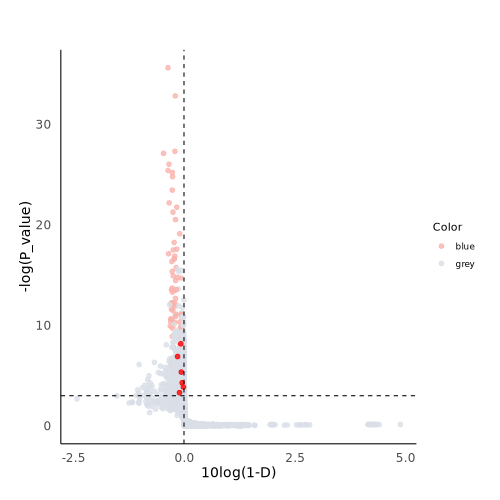

In [93]:
%%R -w 500 -h 500
# Load necessary libraries
library(ggplot2)
library(dplyr)


# Calculate the transformed deduction

# Create a binary color column based on significance and conditions 
filtered_df$Color <- ifelse(
  filtered_df$P_value < 0.05 &
  filtered_df$`10log(1-D)` < 10 * log(1 - 0.001) &
  filtered_df$support_num > 50,
  "blue", 
  "grey"
)
# Mark the 10th row with a unique identifier
filtered_df$Highlight <- FALSE

if (nrow(filtered_df) >= 10) {
  gene_pair1_to_highlight <- "('SDC4', 'PTN')"
  gene_pair2_to_highlight <- "('KRT14', 'ERBB2')"
  gene_pair3_to_highlight <- "('MYH11', 'ANKRD30A')"
  gene_pair4_to_highlight <- "('MYLK', 'MLPH')"
  gene_pair5_to_highlight <- "('MYH11', 'PTN')"
  gene_pair6_to_highlight <- "('ACTA2', 'MLPH')"
  # Create a logical vector for highlighting
  # filtered_df$Highlight <- (filtered_df$gene_pair %in% c(gene_pair1_to_highlight, gene_pair2_to_highlight, gene_pair3_to_highlight))
  filtered_df$Highlight <- (filtered_df$gene_pair %in% c(gene_pair1_to_highlight, gene_pair2_to_highlight, gene_pair3_to_highlight, gene_pair4_to_highlight, gene_pair5_to_highlight, gene_pair6_to_highlight))
}
print(filtered_df[filtered_df$Highlight,])
# Create the volcano plot
p <- ggplot(filtered_df, aes(x = `10log(1-D)`, y = -log(P_value), color = Color)) +
    geom_point(aes(color = Color), size = 2, alpha = 0.8) +  # Points with specified color
    geom_point(data = subset(filtered_df, Highlight == TRUE), color = "red", size = 2, alpha = 0.8) +  # Highlight the 10th point
    scale_color_manual(values = c("grey" = "#D9DEE7", "blue" = "#F9B3AD")) +  # Define explicit colors    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Horizontal line at y=0
    geom_hline(yintercept = -log(0.05), linetype = "dashed", color = "black") +
    geom_vline(xintercept = 10*log(1-0.001), linetype = "dashed", color = "black") +
#     geom_vline(xintercept = 10*log(1), linetype = "dashed", color = "black")+
    theme_minimal() +
    theme(
        plot.margin = margin(t = 50, r = 20, b = 20, l = 20),  # Increase margin
        axis.title.x = element_text(size = 14),    # Increase x-axis label size
        axis.title.y = element_text(size = 14),    # Increase y-axis label size
        axis.text.x = element_text(size = 12),      # Increase x-axis tick label size
        axis.text.y = element_text(size = 12),
        axis.line = element_line(colour = "black"),  # Black axis lines
        panel.border = element_blank(),               # Remove panel border
        panel.grid = element_blank(),                 # Remove grid lines
        axis.ticks.length = unit(0.25, "cm")        # Adjust tick length
    )
ggsave("/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/figures/myo_vs_epi_volcano_plot.png", plot = p, width = 8, height = 8, dpi = 300, bg = "white") 

# Show the plot
print(p)

Visualization of the deduction of the cell-cell perturbatino results.

# For tumor and boundary cell

we set 10 to get the most cloest cell-cell communication

python perturbation_analysis.py -ct1 Tumor -ct2 "Transitional Cells" -adata /home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/croped_sdata_Xenium_breast_tumor.h5ad -pair_num 100 -cci /home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/VUILD96MF_croped_tumor_cell_id.npy -ts Breast -cd Disease -cache_dir /home/sxr280/Spatialformer/cache/ -base_dir /home/sxr280/Spatialformer_6_10 -rd 10 -out_dir /home/sxr280/Spatialformer/downstream/cell_cell_communication/data
    

In [6]:
all_infos = pickle.load(open("/home/sxr280/Spatialformer/downstream/cell_cell_communication/data/all_infos_crop_id_Tumor_Transitional_Cells.pkl", "rb"))
#Optional 1: use the CellChat database
database_path1 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/ligand_receptor_database.csv"
#Optional 2: use the Cellnest database
database_path2 = "/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/data/CellNEST_database.csv"
tumor_tra_pair_df = stat_test(all_infos, vocab)
tumor_tra_pair_df = ovlp_database(tumor_tra_pair_df, database_path1, database_path2)
tumor_tra_ranked_df = filter_df(tumor_tra_pair_df)

100%|██████████| 20860/20860 [00:15<00:00, 1368.04it/s]
/home/sxr280/Spatialformer_6_10/utils/utils.py:1624: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["adj_P_value"] = pvals_corrected


In [7]:
tumor_tra_ranked_df[tumor_tra_ranked_df["ligand_receptor"] == True]

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
699,"(ERBB2, CDH1)",ERBB2,CDH1,-0.008372,10.293103,-4.470114,0.000009,116,"[[epeepcmh-1, epeecona-1], [epeecona-1, epeepc...","[-0.122003496, -0.10312879, -0.07297596, -0.06...",True,-0.121292,-1,0.000779


In [8]:
tumor_tra_ranked_df.sort_values("Deduction")

,gene_pair,gene1,gene2,Deduction,rank_mean,stat,P_value,support_num,top20_cellpairs,top20_diff,ligand_receptor,10log(1-D),symbol,adj_P_value
548,"(KRT14, MYLK)",KRT14,MYLK,-0.046007,21.648148,-2.344151,0.011426,54,"[[fakdnaie-1, fakdnlih-1], [fakdnlih-1, fakdna...","[-0.72718006, -0.65700346, -0.35785535, -0.335...",False,-0.679497,-1,0.018451
118,"(MYLK, SFRP1)",MYLK,SFRP1,-0.034699,19.312500,-2.709127,0.004339,64,"[[fakdnaie-1, fakdnlih-1], [fakdnlih-1, fakdna...","[-0.58636475, -0.5600313, -0.15077454, -0.1363...",False,-0.509498,-1,0.009480
89,"(MYLK, DST)",MYLK,DST,-0.034657,15.000000,-2.492172,0.007551,70,"[[fakdnaie-1, fakdnlih-1], [fakdnlih-1, fakdna...","[-0.71042174, -0.6426917, -0.17456886, -0.1648...",False,-0.508867,-1,0.013924
4984,"(SERHL2, MUC6)",SERHL2,MUC6,-0.033763,14.865385,-3.175722,0.001268,52,"[[epjjekol-1, epjlnmmm-1], [epjlnmmm-1, epjjek...","[-0.3932414, -0.33696532, -0.19035947, -0.1404...",False,-0.495504,-1,0.004338
106,"(MYLK, DSP)",MYLK,DSP,-0.033309,23.529412,-2.384994,0.009958,68,"[[fakdnaie-1, fakdnlih-1], [fakdnlih-1, fakdna...","[-0.67983377, -0.6191269, -0.19440776, -0.1938...",False,-0.488738,-1,0.016703
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,"(ERBB2, LYPD3)",ERBB2,LYPD3,-0.002154,19.515152,-2.120536,0.018891,66,"[[fakdnaie-1, fakdnlih-1], [epeepcmh-1, epeeco...","[-0.031968653, -0.023489356, -0.020148218, -0....",False,-0.031106,-1,0.025987
1340,"(TOMM7, DSC2)",TOMM7,DSC2,-0.002080,32.465517,-3.218621,0.001063,58,"[[fbfmgclh-1, fbfocjlk-1], [epmmlchf-1, epmnjm...","[-0.022417665, -0.013377607, -0.012888253, -0....",False,-0.030033,-1,0.004052
1225,"(RUNX1, ZNF562)",RUNX1,ZNF562,-0.002052,33.518519,-2.957979,0.002309,54,"[[epeecona-1, epeepcmh-1], [fbfmgclh-1, fbfocj...","[-0.021122277, -0.016600192, -0.013864577, -0....",False,-0.029636,-1,0.006320
1365,"(TOMM7, LYPD3)",TOMM7,LYPD3,-0.001795,33.785714,-1.740448,0.043686,56,"[[fakdnlih-1, fakdnaie-1], [fakdnaie-1, fakdnl...","[-0.03788072, -0.029365659, -0.018055499, -0.0...",False,-0.025921,-1,0.045449


Get the top 5 cell pairs

In [102]:
import numpy as np

# Flatten the top20_diff list while keeping track of the row and column indices
ranked_index = []
for row_idx, row in enumerate(tumor_tra_ranked_df["top20_diff"]):
    for col_idx, value in enumerate(row):
        ranked_index.append((value, row_idx, col_idx))

# Sort the flattened list by the top20_diff values
ranked_index = sorted(ranked_index, key=lambda x: x[0])

# Get the top 5 entries while ensuring indices are valid
top = 500

In [128]:
data = {}  # Dictionary to store cell pair data
for _, row_idx, col_idx in ranked_index[:top]:
    # Get the cell pair and ensure it's sorted to avoid inverse duplication
    cell_pair = tumor_tra_ranked_df.iloc[row_idx]["top20_cellpairs"][col_idx]
    cell_pair_sorted = tuple(sorted(cell_pair))  # Sort the cell pair to make it consistent
    gene_pair = tumor_tra_ranked_df.iloc[row_idx]["gene_pair"]
    ded = tumor_tra_ranked_df.iloc[row_idx]["top20_diff"][col_idx]

    # Add the cell pair and corresponding data to the dictionary
    if cell_pair_sorted not in data:
        data[cell_pair_sorted] = {"gene_pairs": [], "cell_pair_ded": []}
    data[cell_pair_sorted]["gene_pairs"].append(gene_pair)
    data[cell_pair_sorted]["cell_pair_ded"].append(ded)

# Convert the dictionary into a DataFrame
cell_pair_df = pd.DataFrame([
    {"cell_pairs": str(cell_pair), "gene_pairs": info["gene_pairs"], "cell_pair_ded": info["cell_pair_ded"]}
    for cell_pair, info in data.items()
])
cell_pair_df["mean_ded"] = cell_pair_df["cell_pair_ded"].map(lambda x: np.mean(x))
cell_pair_df = cell_pair_df.sort_values("mean_ded")

In [129]:
cell_pair_df

,cell_pairs,gene_pairs,cell_pair_ded,mean_ded
0,"('fakdnaie-1', 'fakdnlih-1')","[(MYLK, SCD), (SERHL2, MYLK), (MYLK, ABCC11), ...","[-0.827776, -0.7551924, -0.75104636, -0.738756...",-0.293587
2,"('epjjekol-1', 'epjlnmmm-1')","[(SERHL2, MUC6), (SERHL2, FASN), (SERHL2, DST)...","[-0.3932414, -0.3902839, -0.35457227, -0.34932...",-0.225684
3,"('eobpffal-1', 'eocchhib-1')","[(KRT14, MYLK), (KRT14, MYLK), (KRT14, KRT7), ...","[-0.35785535, -0.33541286, -0.3192845, -0.3103...",-0.185078
1,"('epmmlchf-1', 'epmnjmdd-1')","[(SFRP1, SCD), (SFRP1, SCD), (SCD, DSC2), (SCD...","[-0.5336877, -0.53332376, -0.26990622, -0.2361...",-0.183796
4,"('fbfmgclh-1', 'fbfocjlk-1')","[(KRT7, MYBPC1), (KRT7, MYBPC1), (ERBB2, MYBPC...","[-0.25535595, -0.1861428, -0.15833765, -0.1579...",-0.162362
5,"('faekoekk-1', 'faelfjam-1')","[(MYLK, SCD), (KRT7, SCD), (MYLK, SCD), (MYLK,...","[-0.2448988, -0.13364697, -0.123658, -0.107412...",-0.136355
7,"('enkbofld-1', 'enkcjeen-1')","[(SFRP1, SCD), (SFRP1, SCD), (SERHL2, SFRP1), ...","[-0.1899113, -0.17244428, -0.1594128, -0.15193...",-0.133040
6,"('epeecona-1', 'epeepcmh-1')","[(ERBB2, MUC6), (SERHL2, MUC6), (KRT7, MUC6), ...","[-0.21430469, -0.19035947, -0.18277514, -0.181...",-0.130452
8,"('epcnfocl-1', 'epcngmpf-1')","[(SERHL2, ACTA2), (SERHL2, KRT7), (SERHL2, ERB...","[-0.14047214, -0.12902656, -0.12297608, -0.119...",-0.111194


/tmp/ipykernel_3286471/4147800413.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cell_pair_df_exploded, x="cell_pairs", y="cell_pair_ded", palette="Oranges")
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/seabor

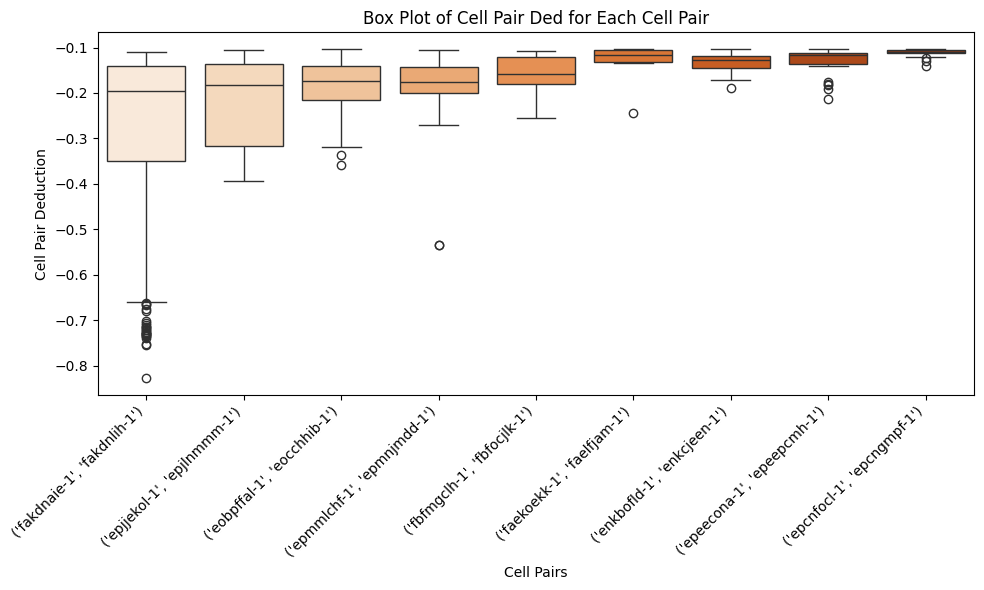

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Explode the 'cell_pair_ded' column so each value is in a separate row
cell_pair_df_exploded = cell_pair_df.explode("cell_pair_ded")

# Convert 'cell_pair_ded' column to numeric
cell_pair_df_exploded["cell_pair_ded"] = pd.to_numeric(cell_pair_df_exploded["cell_pair_ded"])

# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=cell_pair_df_exploded, x="cell_pairs", y="cell_pair_ded", palette="Oranges")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.xlabel("Cell Pairs")
plt.ylabel("Cell Pair Deduction")
plt.title("Box Plot of Cell Pair Ded for Each Cell Pair")
plt.tight_layout()
plt.savefig("/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/figures/boxplot_breast_tumor.png", dpi=300)
# Display the plot
plt.show()

 Visualization of the results

In [9]:
import os
import sys

# Set R_HOME to your path from Step 1
r_home = "/home/sxr280/miniconda3/envs/spatialformer/lib/R" 
if os.path.exists(r_home):
    os.environ['R_HOME'] = r_home
else:
    raise FileNotFoundError(f"R_HOME path not found: {r_home}")

In [10]:
%%capture
%load_ext rpy2.ipython

In [11]:
filtered_df = tumor_tra_pair_df

In [12]:
%R -i filtered_df

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "gene_pair". Fall back to string conversion. The error is: <class 'tuple'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_cellpairs". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "top20_diff". Fall back to string conversion. The error is: <class 'numpy.ndarray'>
  warnings.warn('Error while trying to convert '


            gene_pair gene1 gene2    Deduction rank_mean      stat      P_value
89    ('MYLK', 'DST')  MYLK   DST -0.034657184  15.00000 -2.492172 7.551229e-03
106   ('MYLK', 'DSP')  MYLK   DSP -0.033309370  23.52941 -2.384994 9.957816e-03
118 ('MYLK', 'SFRP1')  MYLK SFRP1 -0.034699392  19.31250 -2.709127 4.338735e-03
548 ('KRT14', 'MYLK') KRT14  MYLK -0.046007235  21.64815 -2.344151 1.142566e-02
699 ('ERBB2', 'CDH1') ERBB2  CDH1 -0.008372049  10.29310 -4.470114 9.214415e-06
    support_num
89           70
106          68
118          64
548          54
699         116
                                                                                                                                                                                                                                                                                                                                                                                                                                        

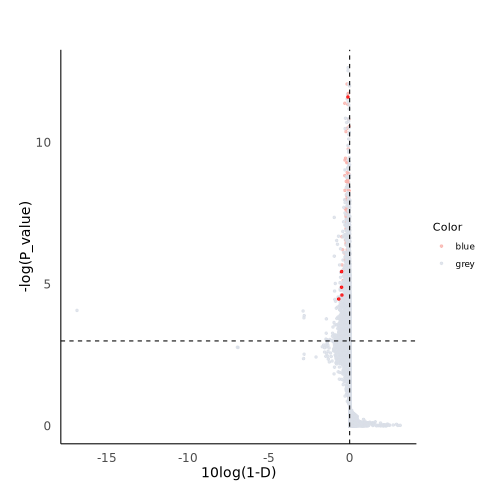

In [15]:
%%R -w 500 -h 500
# Load necessary libraries
library(ggplot2)
library(dplyr)


# Calculate the transformed deduction

# Create a binary color column based on significance and conditions 
filtered_df$Color <- ifelse(
  filtered_df$P_value < 0.05 &
  filtered_df$`10log(1-D)` < 10 * log(1 - 0.001) &
  filtered_df$support_num > 50,
  "blue", 
  "grey"
)
# Mark the 10th row with a unique identifier
filtered_df$Highlight <- FALSE

if (nrow(filtered_df) >= 10) {
  gene_pair1_to_highlight <- "('KRT14', 'MYLK')"
  gene_pair2_to_highlight <- "('MYLK', 'SFRP1')"
  gene_pair3_to_highlight <- "('MYLK', 'DST')"
  gene_pair4_to_highlight <- "('MYLK', 'DSP')"
  gene_pair5_to_highlight <- "('ERBB2', 'CDH1')"
    

  # Create a logical vector for highlighting
  # filtered_df$Highlight <- (filtered_df$gene_pair %in% c(gene_pair1_to_highlight, gene_pair2_to_highlight, gene_pair3_to_highlight))
  filtered_df$Highlight <- (filtered_df$gene_pair %in% c(gene_pair1_to_highlight, gene_pair2_to_highlight, gene_pair3_to_highlight, gene_pair4_to_highlight, gene_pair5_to_highlight))
}
print(filtered_df[filtered_df$Highlight,])
# Create the volcano plot
p <- ggplot(filtered_df, aes(x = `10log(1-D)`, y = -log(P_value), color = Color)) +
    geom_point(aes(color = Color), size = 1, alpha = 0.8) +  # Points with specified color
    geom_point(data = subset(filtered_df, Highlight == TRUE), color = "red", size = 1, alpha = 0.8) +  # Highlight the 10th point
    scale_color_manual(values = c("grey" = "#D9DEE7", "blue" = "#F9B3AD")) +  # Define explicit colors    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +  # Horizontal line at y=0
    geom_hline(yintercept = -log(0.05), linetype = "dashed", color = "black") +
    geom_vline(xintercept = 10*log(1-0.001), linetype = "dashed", color = "black") +
#     geom_vline(xintercept = 10*log(1), linetype = "dashed", color = "black")+
    theme_minimal() +
    theme(
        plot.margin = margin(t = 50, r = 20, b = 20, l = 20),  # Increase margin
        axis.title.x = element_text(size = 14),    # Increase x-axis label size
        axis.title.y = element_text(size = 14),    # Increase y-axis label size
        axis.text.x = element_text(size = 12),      # Increase x-axis tick label size
        axis.text.y = element_text(size = 12),
        axis.line = element_line(colour = "black"),  # Black axis lines
        panel.border = element_blank(),               # Remove panel border
        panel.grid = element_blank(),                 # Remove grid lines
        axis.ticks.length = unit(0.25, "cm")        # Adjust tick length
    )
ggsave("/home/sxr280/Spatialformer_6_10/downstream/cell_cell_communication/figures/tumor_vs_boundary_volcano_plot.png", plot = p, width = 8, height = 8, dpi = 300, bg = "white") 

# Show the plot
print(p)

In [136]:
%R -i cell_pair_df

/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "gene_pairs". Fall back to string conversion. The error is: <class 'list'>
  warnings.warn('Error while trying to convert '
/home/sxr280/miniconda3/envs/spatialformer/lib/python3.9/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "cell_pair_ded". Fall back to string conversion. The error is: <class 'list'>
  warnings.warn('Error while trying to convert '


In [138]:
cell_pair_df

,cell_pairs,gene_pairs,cell_pair_ded,mean_ded
0,"('fakdnaie-1', 'fakdnlih-1')","[(MYLK, SCD), (SERHL2, MYLK), (MYLK, ABCC11), ...","[-0.827776, -0.7551924, -0.75104636, -0.738756...",-0.293587
2,"('epjjekol-1', 'epjlnmmm-1')","[(SERHL2, MUC6), (SERHL2, FASN), (SERHL2, DST)...","[-0.3932414, -0.3902839, -0.35457227, -0.34932...",-0.225684
3,"('eobpffal-1', 'eocchhib-1')","[(KRT14, MYLK), (KRT14, MYLK), (KRT14, KRT7), ...","[-0.35785535, -0.33541286, -0.3192845, -0.3103...",-0.185078
1,"('epmmlchf-1', 'epmnjmdd-1')","[(SFRP1, SCD), (SFRP1, SCD), (SCD, DSC2), (SCD...","[-0.5336877, -0.53332376, -0.26990622, -0.2361...",-0.183796
4,"('fbfmgclh-1', 'fbfocjlk-1')","[(KRT7, MYBPC1), (KRT7, MYBPC1), (ERBB2, MYBPC...","[-0.25535595, -0.1861428, -0.15833765, -0.1579...",-0.162362
5,"('faekoekk-1', 'faelfjam-1')","[(MYLK, SCD), (KRT7, SCD), (MYLK, SCD), (MYLK,...","[-0.2448988, -0.13364697, -0.123658, -0.107412...",-0.136355
7,"('enkbofld-1', 'enkcjeen-1')","[(SFRP1, SCD), (SFRP1, SCD), (SERHL2, SFRP1), ...","[-0.1899113, -0.17244428, -0.1594128, -0.15193...",-0.133040
6,"('epeecona-1', 'epeepcmh-1')","[(ERBB2, MUC6), (SERHL2, MUC6), (KRT7, MUC6), ...","[-0.21430469, -0.19035947, -0.18277514, -0.181...",-0.130452
8,"('epcnfocl-1', 'epcngmpf-1')","[(SERHL2, ACTA2), (SERHL2, KRT7), (SERHL2, ERB...","[-0.14047214, -0.12902656, -0.12297608, -0.119...",-0.111194


# A tibble: 6 × 4
  cell_pairs                   gene_pairs                 cell_pair_ded mean_ded
  <chr>                        <chr>                      <chr>            <dbl>
1 ('fakdnaie-1', 'fakdnlih-1') [('MYLK', 'SCD'), ('SERHL… [-0.827776, …   -0.294
2 ('epjjekol-1', 'epjlnmmm-1') [('SERHL2', 'MUC6'), ('SE… [-0.3932414,…   -0.226
3 ('eobpffal-1', 'eocchhib-1') [('KRT14', 'MYLK'), ('KRT… [-0.35785535…   -0.185
4 ('epmmlchf-1', 'epmnjmdd-1') [('SFRP1', 'SCD'), ('SFRP… [-0.5336877,…   -0.184
5 ('fbfmgclh-1', 'fbfocjlk-1') [('KRT7', 'MYBPC1'), ('KR… [-0.25535595…   -0.162
6 ('faekoekk-1', 'faelfjam-1') [('MYLK', 'SCD'), ('KRT7'… [-0.2448988,…   -0.136


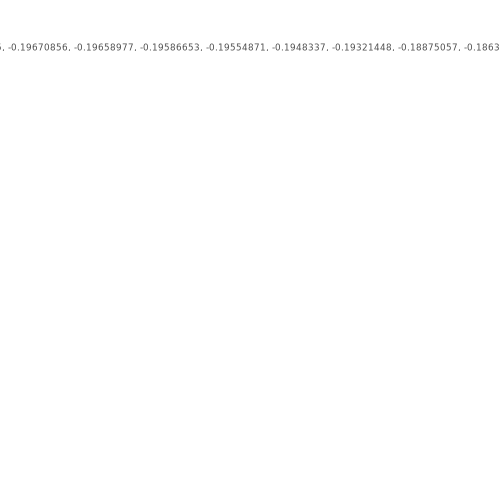

In [145]:
%%R -w 500 -h 500
# Load necessary libraries
library(ggplot2)
library(tidyr)
library(dplyr)  # Required for the pipe operator (%>%)

# Ensure cell_pair_df exists and has the correct structure
# Unnest the list column `cell_pair_ded` so each value is in a separate row
data_long <- cell_pair_df %>% 
  unnest(cell_pair_ded)

# Print data for debugging
print(head(data_long))

# Create the box plot
q <- ggplot(data_long, aes(x = cell_pairs, y = cell_pair_ded)) +
  geom_boxplot(fill = "skyblue", color = "black") +
  labs(
    title = "Box Plot of Cell Pair Ded for Each Cell Pair",
    x = "Cell Pairs",
    y = "Cell Pair Ded"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Print the plot
print(q)